## Problem: When arriving at the Doan Hall stop, the bus is already full from the UH stop. 

### Goals:

- Break down boardings and alightings by stop (UH and Doan) in 30 minute intervals 
- Sample data from approximately 4/1/2026 - 4/14/2026
- 9am timeframe investigated here.

---

Ultimate goal is to determine if full busses are coming TO Doan FROM UH and pinpoint the timeframe of when the problem is occuring.

---

**NOTES:**
- This is limited by accuracy of the APCs
- No data exists for people 'waiting' for a bus to my knowledge
- This is descriptive of past events and does not necessarily predict future patterns
- I cannot say why busses are overcrowding, only can determine if and when

In [1]:
# # Should only have to run 1x here/
# from modules import busstate_processing as bp

# # Should contain data from 4/1/2026 to present 4/16/2026
# bp.busstate_processing(year = "26", month = "08", current_dir = "K:/AP/TTM/Data/WMC_Dashboard/") #stored initial in /analysis_data if needed in future

In [2]:
import pandas as pd
# original data (4/1/2026 - 4/15/2026) is additionally stored in K:/AP/TTM/Data/WMC_Dashboard/analysis_data
import sys
import os

# go up one level from notebook folder
# sys.path.append(os.path.abspath(".."))
from modules import med_center_dashboard as mcd

# ok - busstate data is stored in K:/AP/TTM/Data/WMC_Dashboard/analysis_data
# this contains from 4/1/2026 to present

aug_df = pd.read_csv("K:/AP/TTM/Data/WMC_Dashboard/busstate_cleaned/2026-AUG-busstate.csv")

aug_mc_df = mcd.process_mc_busstate(year = "2026",month = "AUG", current_dir="K:/AP/TTM/Data/WMC_Dashboard/busstate_cleaned")

aug_mc_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 38860 entries, 0 to 38859
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype          
---  ------      --------------  -----          
 0   BUS_ID      38860 non-null  int64          
 1   DATE        38860 non-null  datetime64[us] 
 2   COUNT       38860 non-null  int64          
 3   STOP_ID     38860 non-null  int64          
 4   BOARDINGS   38860 non-null  int64          
 5   ALIGHTINGS  38860 non-null  int64          
 6   LOAD        38860 non-null  int64          
 7   RUN_ID      38860 non-null  float64        
 8   DEST        38860 non-null  str            
 9   ARRIVAL     38860 non-null  datetime64[us] 
 10  DEPARTURE   38860 non-null  datetime64[us] 
 11  DWELL       38860 non-null  timedelta64[us]
 12  HOUR        38860 non-null  int32          
 13  MINUTE      38860 non-null  int32          
dtypes: datetime64[us](3), float64(1), int32(2), int64(6), str(1), timedelta64[us](1)
memory usage: 3.9 MB


In [3]:
# cut down to only doan 37 and UH 401
# should now only have info for UH and Doan stops
uh_doan_apr_mc_df = aug_mc_df[(aug_mc_df['STOP_ID'] == 401) | (aug_mc_df['STOP_ID'] == 37)]

uh_doan_apr_mc_df

,BUS_ID,DATE,COUNT,STOP_ID,BOARDINGS,ALIGHTINGS,LOAD,RUN_ID,DEST,ARRIVAL,DEPARTURE,DWELL,HOUR,MINUTE
4,1301,2026-08-18,5,401,6,4,16,1502.0,MC,1900-01-01 14:04:59,1900-01-01 14:05:41,0 days 00:00:42,14,4
5,1301,2026-08-18,6,37,6,10,12,1502.0,MC,1900-01-01 14:06:15,1900-01-01 14:07:54,0 days 00:01:39,14,6
10,1301,2026-08-18,11,401,4,8,5,1502.0,MC,1900-01-01 14:26:46,1900-01-01 14:28:14,0 days 00:01:28,14,26
11,1301,2026-08-18,12,37,5,2,4,1502.0,MC,1900-01-01 14:28:47,1900-01-01 14:30:17,0 days 00:01:30,14,28
16,1301,2026-08-18,17,401,5,14,13,1502.0,MC,1900-01-01 14:50:26,1900-01-01 14:51:08,0 days 00:00:42,14,50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38847,2503,2026-08-31,38836,37,4,1,5,1507.0,MC,1900-01-01 19:07:43,1900-01-01 19:09:37,0 days 00:01:54,19,7
38852,2503,2026-08-31,38841,401,35,0,35,1507.0,MC,1900-01-01 19:26:31,1900-01-01 19:29:53,0 days 00:03:22,19,26
38853,2503,2026-08-31,38842,37,11,0,46,1507.0,MC,1900-01-01 19:30:30,1900-01-01 19:32:10,0 days 00:01:40,19,30
38858,2503,2026-08-31,38847,401,3,1,2,1507.0,MC,1900-01-01 19:50:00,1900-01-01 19:51:35,0 days 00:01:35,19,50


In [4]:
# import visualization libraries
# %pip install seaborn matplotlib

import seaborn as sns
import matplotlib.pyplot as plt 

## Side by side stop comparison

In [5]:
# cut down sample data to date, time of arrival, stop, boardings, and alightings 
temp = uh_doan_apr_mc_df[['DATE', 'ARRIVAL', 'STOP_ID', 'BOARDINGS', 'ALIGHTINGS']]

# combine date and arrival time to single col
temp['TIME'] = pd.to_datetime(temp['DATE'].astype(str) + ' ' + temp['ARRIVAL'].dt.time.astype(str))
temp.drop(['DATE', 'ARRIVAL'], axis=1, inplace=True)

# break apart timeframes into 30 min intervals - not keeping date specifically
# temp['BUCKET'] = temp['TIME'].dt.floor('30Min').dt.time

# cut down bucket to hr/min, dont need sec
# true 30-min bucket, no date shown
temp['BUCKET'] = temp['TIME'].dt.floor('30min').dt.strftime('%H:%M')

# create a 'net' colum as boardings - alightings
# directional, negative indicates bus 'emptying' passengers, positive indicates bus 'filling' passengers
mc_df = temp.copy()
mc_df['NET'] = mc_df['BOARDINGS'] - mc_df['ALIGHTINGS'] # net indicates PER STOP

# this did NOT work at all
# # sort by stop and time and get a "running load"?
# mc_df.sort_values(['TIME'], inplace=True)
# mc_df['RUNNING_LOAD'] = mc_df.groupby('STOP_ID')['NET'].cumsum()

mc_df

,STOP_ID,BOARDINGS,ALIGHTINGS,TIME,BUCKET,NET
4,401,6,4,2026-08-18 14:04:59,14:00,2
5,37,6,10,2026-08-18 14:06:15,14:00,-4
10,401,4,8,2026-08-18 14:26:46,14:00,-4
11,37,5,2,2026-08-18 14:28:47,14:00,3
16,401,5,14,2026-08-18 14:50:26,14:30,-9
...,...,...,...,...,...,...
38847,37,4,1,2026-08-31 19:07:43,19:00,3
38852,401,35,0,2026-08-31 19:26:31,19:00,35
38853,37,11,0,2026-08-31 19:30:30,19:30,11
38858,401,3,1,2026-08-31 19:50:00,19:30,2


In [6]:
# Summary stats of the dataset I am working with here
mc_df.describe()

,STOP_ID,BOARDINGS,ALIGHTINGS,TIME,NET
count,13473.000000,13473.000000,13473.000000,13473,13473.000000
mean,217.122319,4.349811,4.294441,2026-08-16 18:10:13.782824,0.055370
min,37.000000,0.000000,0.000000,2026-08-01 00:00:32,-47.000000
25%,37.000000,0.000000,0.000000,2026-08-10 06:48:48,-5.000000
50%,37.000000,2.000000,2.000000,2026-08-17 13:26:28,0.000000
75%,401.000000,6.000000,6.000000,2026-08-24 17:59:02,4.000000
max,401.000000,61.000000,65.000000,2026-08-31 23:56:06,56.000000
std,181.997068,6.545646,5.959838,NaN,9.662332


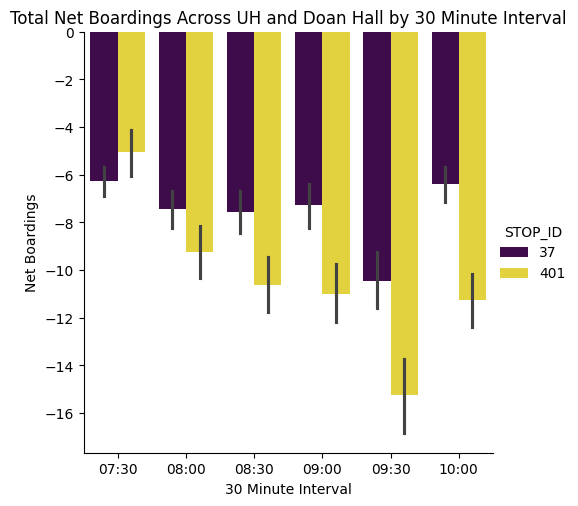

In [7]:
sns.set_palette("viridis_r")

# cut down sample data to doan hall and uh stops separately
# cut down to 1:30pm - 4:30pm for a buffer
mc_df = mc_df[(mc_df['TIME'].dt.time > pd.to_datetime('07:30').time()) & (mc_df['TIME'].dt.time <= pd.to_datetime('10:30').time())]
mc_df = mc_df.sort_values(by='TIME')

uh_df = mc_df[mc_df['STOP_ID'] == 401]
doan_df = mc_df[mc_df['STOP_ID'] == 37]


plot = sns.catplot(
    data = mc_df,
    x = 'BUCKET',
    y = 'NET',
    hue = 'STOP_ID',
    kind = 'bar',
    palette = "viridis"
)
plot.set(title = "Total Net Boardings Across UH and Doan Hall by 30 Minute Interval")
plot.set_axis_labels("30 Minute Interval", "Net Boardings")
plt.show()

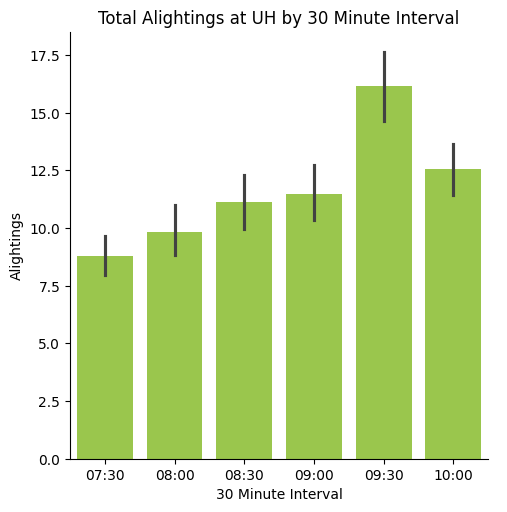

In [8]:
# plot UH individually
# alightings
plot = sns.catplot(
    data = uh_df,
    x = 'BUCKET',
    y = 'ALIGHTINGS',
    kind = 'bar'
)
plot.set(title = "Total Alightings at UH by 30 Minute Interval")
plot.set_axis_labels("30 Minute Interval", "Alightings")
plt.show()

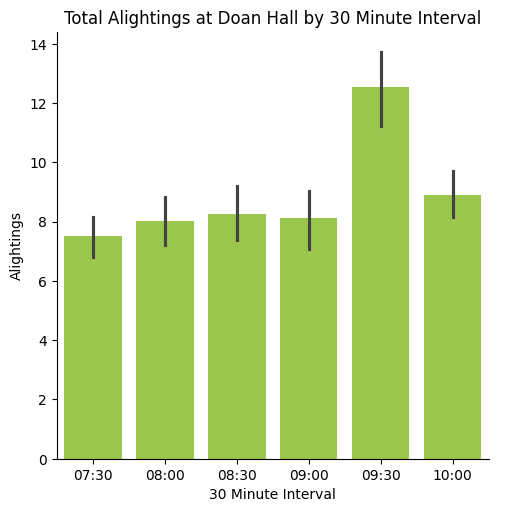

In [9]:
# plot Doan Hall individually
plot = sns.catplot(
    data = doan_df,
    x = 'BUCKET',
    y = 'ALIGHTINGS',
    kind = 'bar'
)
plot.set(title = "Total Alightings at Doan Hall by 30 Minute Interval")
plot.set_axis_labels("30 Minute Interval", "Alightings")
plt.show()

### NOTES:

- Clear outbound traffic in this time interval. 
- Capacity seems to be mostly evenly distributed between alighting at UH and at Doan
- 9:30 hour is has the most capacity of alightings so far

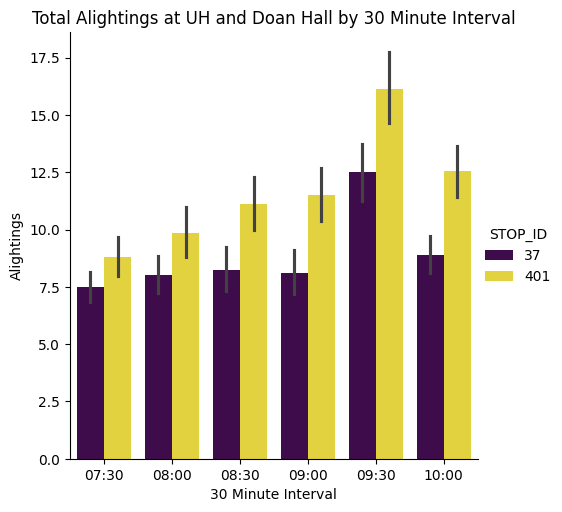

In [10]:
# Break apart boardings for UH and Doan Hall
plot = sns.catplot(
    data = mc_df,
    x = 'BUCKET',
    y = 'ALIGHTINGS',
    hue = 'STOP_ID',
    kind = 'bar',
    palette = "viridis"
)
plot.set(title = "Total Alightings at UH and Doan Hall by 30 Minute Interval")
plot.set_axis_labels("30 Minute Interval", "Alightings")
plt.show()

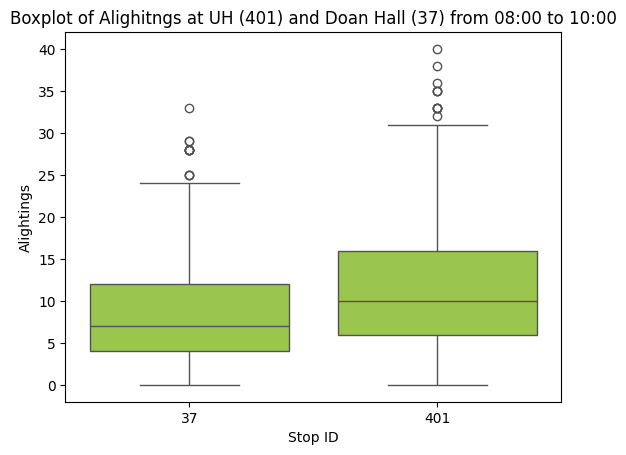

In [11]:
# quick outlier assessment
# cut down exactly to desired timeframe
temp = mc_df[(mc_df['TIME'].dt.time >= pd.to_datetime('08:00').time()) & (mc_df['TIME'].dt.time <= pd.to_datetime('10:00').time())]

sns.boxplot(data=temp, x='STOP_ID', y='ALIGHTINGS')
plt.title("Boxplot of Alighitngs at UH (401) and Doan Hall (37) from 08:00 to 10:00")
plt.xlabel("Stop ID")
plt.ylabel("Alightings")
plt.show()

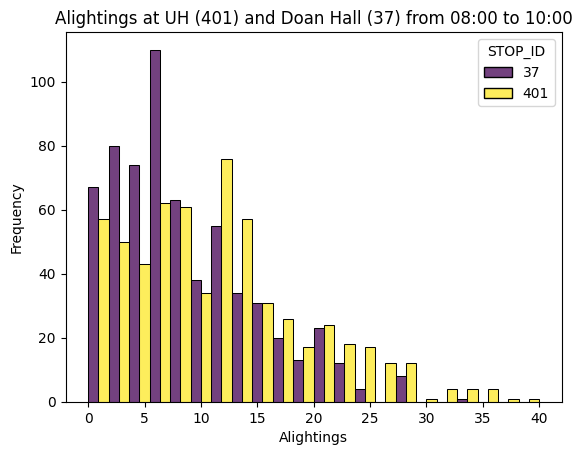

In [12]:
# Generate histogram of boardings at UH and Doan Hall from 14:00 to 16:00
sns.histplot(data=temp, x='ALIGHTINGS', hue='STOP_ID', multiple='dodge', palette="viridis")
plt.title("Alightings at UH (401) and Doan Hall (37) from 08:00 to 10:00")
plt.xlabel("Alightings")
plt.ylabel("Frequency")
plt.show()

### NOTES:
- Alightings in the morning are a lot less skewed than the boardings in the afternoon.
- 

In [13]:
# Look at the top quartile of alightings at each stop?

max_threshold_uh = 30 # choosing 3- for both to get a view of the top end of alightings
max_threshold_doan = 30

doan_outliers = temp[(temp['STOP_ID'] == 37) & (temp['ALIGHTINGS'] > max_threshold_doan)]
doan_outliers # only 1 outlier for Doan - not too concerned about this

,STOP_ID,BOARDINGS,ALIGHTINGS,TIME,BUCKET,NET
9547,37,0,33,2026-08-21 09:16:01,09:00,-33


In [14]:
uh_outliers = temp[(temp['STOP_ID'] == 401) & (temp['ALIGHTINGS'] > max_threshold_uh)]
uh_outliers

,STOP_ID,BOARDINGS,ALIGHTINGS,TIME,BUCKET,NET
14692,401,0,31,2026-08-05 09:36:36,09:30,-31
5955,401,2,32,2026-08-13 08:28:38,08:00,-30
29765,401,2,36,2026-08-18 08:55:04,08:30,-34
29771,401,1,33,2026-08-18 09:16:47,09:00,-32
30253,401,1,38,2026-08-20 09:18:44,09:00,-37
30727,401,0,35,2026-08-24 08:57:15,08:30,-35
30963,401,0,33,2026-08-25 08:59:01,08:30,-33
31217,401,0,33,2026-08-26 09:40:05,09:30,-33
12700,401,2,31,2026-08-27 08:01:29,08:00,-29
31471,401,0,35,2026-08-27 09:18:45,09:00,-35


In [15]:
# Goal - get the context of these total outliers paired with the subsequent Doan Hall boardings
# Goal - get the context of these total outliers paired with the subsequent Doan Hall boardings
outlier_mask = (temp['STOP_ID'] == 401) & (temp['ALIGHTINGS'] > max_threshold_uh)
subsequent_doan_mask = (temp.index.isin(temp.index[outlier_mask] + 1)) & (temp['STOP_ID'] == 37)

total_outliers = temp[outlier_mask | subsequent_doan_mask].sort_index()
total_outliers.sort_values(by = 'TIME')

,STOP_ID,BOARDINGS,ALIGHTINGS,TIME,BUCKET,NET
14692,401,0,31,2026-08-05 09:36:36,09:30,-31
14693,37,7,16,2026-08-05 09:37:55,09:30,-9
5955,401,2,32,2026-08-13 08:28:38,08:00,-30
5956,37,4,21,2026-08-13 08:30:17,08:30,-17
29765,401,2,36,2026-08-18 08:55:04,08:30,-34
29766,37,3,17,2026-08-18 08:56:16,08:30,-14
29771,401,1,33,2026-08-18 09:16:47,09:00,-32
29772,37,2,12,2026-08-18 09:17:49,09:00,-10
30253,401,1,38,2026-08-20 09:18:44,09:00,-37
30254,37,2,16,2026-08-20 09:19:43,09:00,-14


#### NOTES:
- There are very full busses sporadically from approximately **8:55am - 9:45am**
- The busses seem to be evenly alighting at both UH and Doan
    - This makes sense as people getting on at Carmack would not be separated by which stop they intend to get off at
    - Again, there is no way for me to say for sure that people are not waiting at for the next bus at carmack, etc.


In [16]:
# Going to see what the loading at Carmack stops looks like
aug_mc_df['STOP_ID'].value_counts()

STOP_ID
403    6928
404    6922
37     6806
401    6667
95     5772
94     5765
Name: count, dtype: int64

In [17]:
CARMACK_2 = 403
CARMACK_3 = 404
CARMACK_5A = 94
CARMACK_5B = 95

# Subsetting the Carmack stops to see total boardings
carmack_stop_ids = [CARMACK_2, CARMACK_3, CARMACK_5A, CARMACK_5B]
carmack_boardings_df = aug_mc_df[aug_mc_df['STOP_ID'].isin(carmack_stop_ids)]

carmack_boardings_df

,BUS_ID,DATE,COUNT,STOP_ID,BOARDINGS,ALIGHTINGS,LOAD,RUN_ID,DEST,ARRIVAL,DEPARTURE,DWELL,HOUR,MINUTE
0,1301,2026-08-18,1,403,10,0,10,1502.0,MC,1900-01-01 13:54:50,1900-01-01 13:55:49,0 days 00:00:59,13,54
1,1301,2026-08-18,2,404,1,0,11,1502.0,MC,1900-01-01 13:56:43,1900-01-01 13:57:16,0 days 00:00:33,13,56
2,1301,2026-08-18,3,94,2,0,13,1502.0,MC,1900-01-01 13:58:20,1900-01-01 13:58:49,0 days 00:00:29,13,58
3,1301,2026-08-18,4,95,1,0,14,1502.0,MC,1900-01-01 13:59:29,1900-01-01 13:59:58,0 days 00:00:29,13,59
6,1301,2026-08-18,7,403,5,6,11,1502.0,MC,1900-01-01 14:15:18,1900-01-01 14:16:43,0 days 00:01:25,14,15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38851,2503,2026-08-31,38840,95,0,0,0,1507.0,MC,1900-01-01 19:20:42,1900-01-01 19:21:15,0 days 00:00:33,19,20
38854,2503,2026-08-31,38843,403,1,26,21,1507.0,MC,1900-01-01 19:38:39,1900-01-01 19:40:08,0 days 00:01:29,19,38
38855,2503,2026-08-31,38844,404,0,14,7,1507.0,MC,1900-01-01 19:40:43,1900-01-01 19:41:44,0 days 00:01:01,19,40
38856,2503,2026-08-31,38845,94,0,7,7,1507.0,MC,1900-01-01 19:42:45,1900-01-01 19:43:33,0 days 00:00:48,19,42


In [18]:
# cut down sample data to date, time of arrival, stop, boardings, and alightings 
temp = carmack_boardings_df[['DATE', 'ARRIVAL', 'STOP_ID', 'BOARDINGS', 'ALIGHTINGS']]

# combine date and arrival time to single col
temp['TIME'] = pd.to_datetime(temp['DATE'].astype(str) + ' ' + temp['ARRIVAL'].dt.time.astype(str))
temp.drop(['DATE', 'ARRIVAL'], axis=1, inplace=True)

# break apart timeframes into 30 min intervals - not keeping date specifically
# temp['BUCKET'] = temp['TIME'].dt.floor('30Min').dt.time

# cut down bucket to hr/min, dont need sec
# true 30-min bucket, no date shown
temp['BUCKET'] = temp['TIME'].dt.floor('30min').dt.strftime('%H:%M')

cm_mc_df = temp.copy()
cm_mc_df.sort_values(by='BUCKET', inplace=True)
cm_mc_df

,STOP_ID,BOARDINGS,ALIGHTINGS,TIME,BUCKET
2316,403,0,0,2026-08-24 00:28:45,00:00
2470,404,0,1,2026-08-26 00:01:10,00:00
3562,403,0,0,2026-08-06 00:09:44,00:00
3563,404,0,1,2026-08-06 00:10:41,00:00
3564,94,0,0,2026-08-06 00:12:03,00:00
...,...,...,...,...,...
36267,95,0,1,2026-08-14 23:34:15,23:30
36270,403,0,3,2026-08-14 23:49:53,23:30
36271,404,0,4,2026-08-14 23:51:34,23:30
36272,94,0,0,2026-08-14 23:53:26,23:30


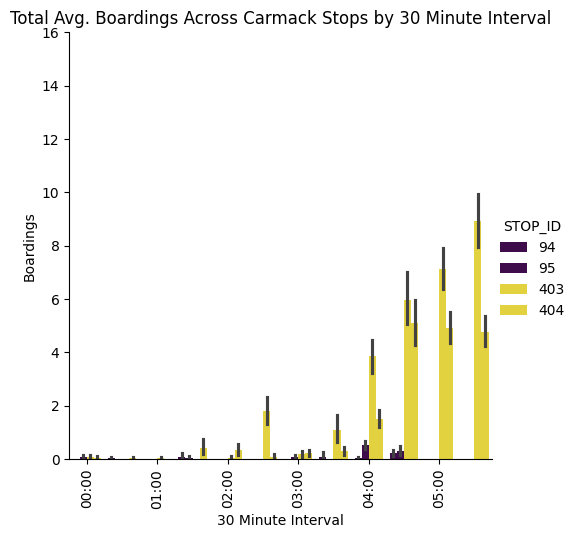

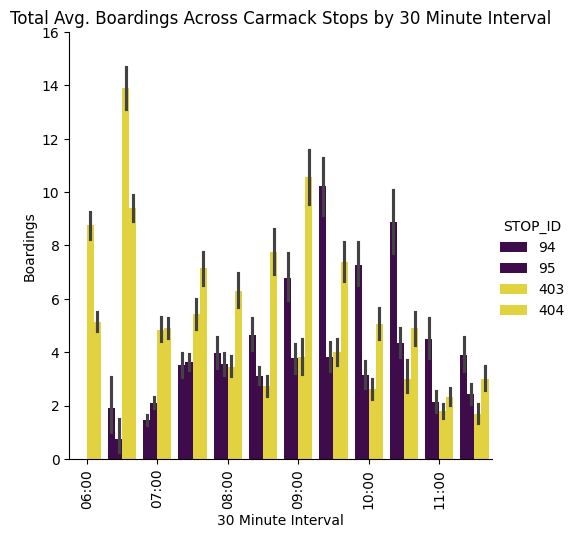

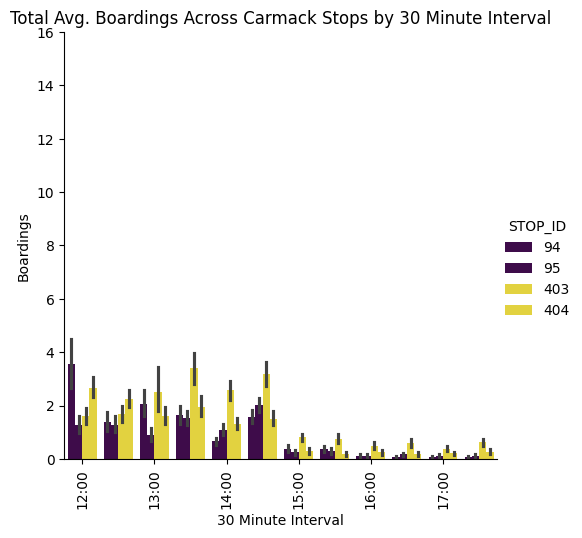

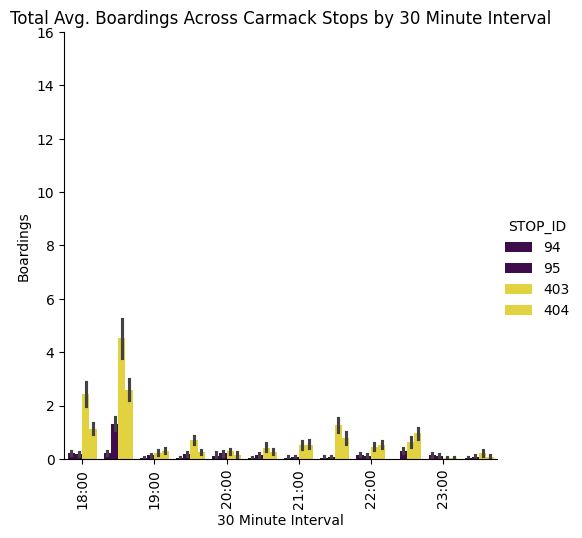

In [19]:
# Plot the average boardings at all 4 carmack stops by 30 min interval
# break apart into 4 plots across 6 hours each
# 0000 - 0600
cm_mc_df_0_6 = cm_mc_df[(cm_mc_df['TIME'].dt.time >= pd.to_datetime('00:00').time()) & (cm_mc_df['TIME'].dt.time < pd.to_datetime('06:00').time())] 

plot = sns.catplot(
    data = cm_mc_df_0_6,
    x = 'BUCKET',
    y = 'BOARDINGS',
    hue = 'STOP_ID',
    kind = 'bar',
    palette = "viridis"
)
plot.set(title = "Total Avg. Boardings Across Carmack Stops by 30 Minute Interval")
plot.set_axis_labels("30 Minute Interval", "Boardings")
plt.ylim(0,16)
plt.xticks(rotation=90, ticks=range(0, len(cm_mc_df_0_6['BUCKET'].unique()), 2))
plt.show()

# 0600 - 1200
cm_mc_df_6_12 = cm_mc_df[(cm_mc_df['TIME'].dt.time >= pd.to_datetime('06:00').time()) & (cm_mc_df['TIME'].dt.time < pd.to_datetime('12:00').time())] 

plot = sns.catplot(
    data = cm_mc_df_6_12,
    x = 'BUCKET',
    y = 'BOARDINGS',
    hue = 'STOP_ID',
    kind = 'bar',
    palette = "viridis"
)
plot.set(title = "Total Avg. Boardings Across Carmack Stops by 30 Minute Interval")
plot.set_axis_labels("30 Minute Interval", "Boardings")
plt.ylim(0,16)
plt.xticks(rotation=90, ticks=range(0, len(cm_mc_df_6_12['BUCKET'].unique()), 2))
plt.show()

# 1200 - 1800
cm_mc_df_12_18 = cm_mc_df[(cm_mc_df['TIME'].dt.time >= pd.to_datetime('12:00').time()) & (cm_mc_df['TIME'].dt.time < pd.to_datetime('18:00').time())] 

plot = sns.catplot(
    data = cm_mc_df_12_18,
    x = 'BUCKET',
    y = 'BOARDINGS',
    hue = 'STOP_ID',
    kind = 'bar',
    palette = "viridis"
)
plot.set(title = "Total Avg. Boardings Across Carmack Stops by 30 Minute Interval")
plot.set_axis_labels("30 Minute Interval", "Boardings")
plt.ylim(0,16)
plt.xticks(rotation=90, ticks=range(0, len(cm_mc_df_12_18['BUCKET'].unique()), 2))
plt.show()

# 1800 - 0000
cm_mc_df_18_0 = cm_mc_df[(cm_mc_df['TIME'].dt.time >= pd.to_datetime('18:00').time()) & (cm_mc_df['TIME'].dt.time < pd.to_datetime('23:59').time())] 

plot = sns.catplot(
    data = cm_mc_df_18_0,
    x = 'BUCKET',
    y = 'BOARDINGS',
    hue = 'STOP_ID',
    kind = 'bar',
    palette = "viridis"
)
plot.set(title = "Total Avg. Boardings Across Carmack Stops by 30 Minute Interval")
plot.set_axis_labels("30 Minute Interval", "Boardings")
plt.ylim(0,16)
plt.xticks(rotation=90, ticks=range(0, len(cm_mc_df_18_0['BUCKET'].unique()), 2))
plt.show()

### NOTES:
- 1900 -> 0500 has very little ridership 
- Small peal exists at 1800 for boardings
- Can see a relatively normal dist of both CM2/CM3 and CM5 with CM5 being offset, presumably due to CM2/CM3 lots filling up
- 

In [20]:
# Total sums by 30-min bucket across all Carmack stops
bucket_totals = (
    cm_mc_df.groupby('BUCKET', as_index=False)[['BOARDINGS', 'ALIGHTINGS']]
    .sum()
    .sort_values('BUCKET')
)

bucket_totals

,BUCKET,BOARDINGS,ALIGHTINGS
0,00:00,15,104
1,00:30,2,81
2,01:00,1,107
3,01:30,14,56
4,02:00,20,31
5,02:30,49,26
6,03:00,24,33
7,03:30,68,21
8,04:00,418,14
9,04:30,943,28


<Axes: xlabel='STOP_ID', ylabel='BUCKET'>

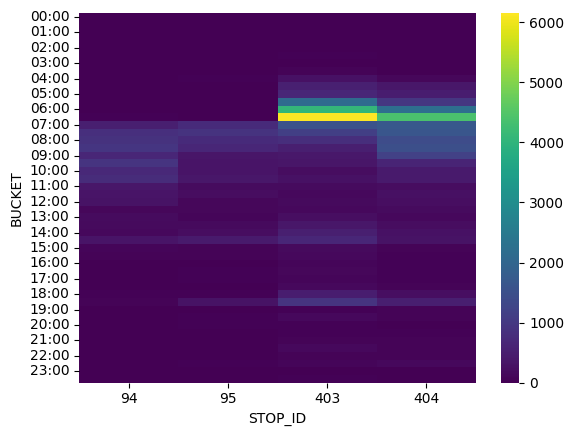

In [21]:
# Heatmap of boardings by stop and 30-min bucket
heatmap_data = cm_mc_df.pivot_table(index='BUCKET', columns='STOP_ID', values='BOARDINGS', aggfunc='sum').fillna(0)
sns.heatmap(heatmap_data, cmap='viridis')

Boardings by 30-minute bucket:
BUCKET  BOARDINGS  ALIGHTINGS  NET
 08:00       3816         364 3452
 08:30       3614         181 3433
 09:00       2588         170 2418
 09:30       2222         218 2004

Boardings by stop:
 STOP_ID  BOARDINGS  ALIGHTINGS
     404       4686         230
      94       3418          78
      95       2089          87
     403       2047         538

Peak boarding bucket:
BUCKET  BOARDINGS  ALIGHTINGS  NET
 08:00       3816         364 3452

Peak boarding stop:
 STOP_ID  BOARDINGS  ALIGHTINGS
     404       4686         230


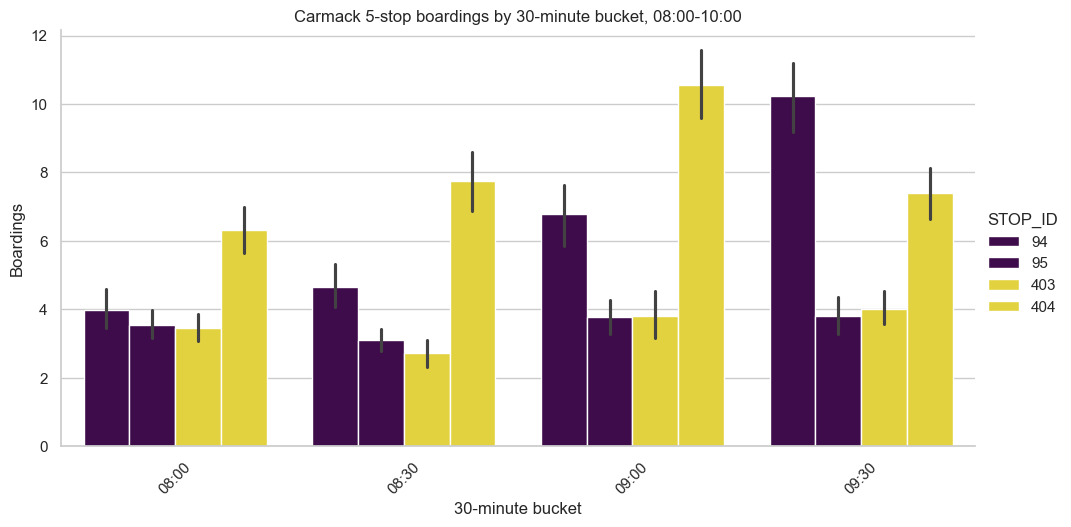

In [22]:
# Investigation: 8–10am window at the Carmack 5 stops
# Focus on stops 403, 404, 94, and 95

CARMACK_2 = 403
CARMACK_3 = 404
CARMACK_5A = 94
CARMACK_5B = 95

carmack_stop_ids = [CARMACK_2, CARMACK_3, CARMACK_5A, CARMACK_5B]
carmack_8_10 = aug_mc_df[aug_mc_df['STOP_ID'].isin(carmack_stop_ids)].copy()

carmack_8_10['TIME'] = pd.to_datetime(
    carmack_8_10['DATE'].astype(str) + ' ' + carmack_8_10['ARRIVAL'].dt.time.astype(str)
)
carmack_8_10 = carmack_8_10[
    (carmack_8_10['TIME'].dt.time >= pd.to_datetime('08:00').time()) &
    (carmack_8_10['TIME'].dt.time < pd.to_datetime('10:00').time())
].copy()
carmack_8_10['BUCKET'] = carmack_8_10['TIME'].dt.floor('30min').dt.strftime('%H:%M')

by_bucket = (
    carmack_8_10.groupby('BUCKET', as_index=False)[['BOARDINGS', 'ALIGHTINGS']]
    .sum()
    .sort_values('BUCKET')
)
by_bucket['NET'] = by_bucket['BOARDINGS'] - by_bucket['ALIGHTINGS']

by_stop = (
    carmack_8_10.groupby('STOP_ID', as_index=False)[['BOARDINGS', 'ALIGHTINGS']]
    .sum()
    .sort_values('BOARDINGS', ascending=False)
)

peak_bucket = by_bucket.sort_values('BOARDINGS', ascending=False).head(1)
peak_stop = by_stop.sort_values('BOARDINGS', ascending=False).head(1)

print('Boardings by 30-minute bucket:')
print(by_bucket[['BUCKET','BOARDINGS','ALIGHTINGS','NET']].to_string(index=False))
print('\nBoardings by stop:')
print(by_stop.to_string(index=False))
print('\nPeak boarding bucket:')
print(peak_bucket[['BUCKET','BOARDINGS','ALIGHTINGS','NET']].to_string(index=False))
print('\nPeak boarding stop:')
print(peak_stop.to_string(index=False))

sns.set_theme(style='whitegrid')
plot = sns.catplot(
    data=carmack_8_10,
    x='BUCKET',
    y='BOARDINGS',
    hue='STOP_ID',
    kind='bar',
    palette='viridis',
    height=5,
    aspect=2,
)
plot.set(title='Carmack 5-stop boardings by 30-minute bucket, 08:00-10:00')
plot.set_axis_labels('30-minute bucket', 'Boardings')
plt.xticks(rotation=45)
plt.show()


In [23]:
# Highest combined boardings by a single bus trip across Carmack stops
# Uses a single bus/date/run as the trip unit, then sums all four stops for that trip

trip_stop = (
    carmack_8_10.groupby(['DATE', 'BUS_ID', 'RUN_ID', 'STOP_ID'], as_index=False)['BOARDINGS']
    .sum()
    .sort_values(['DATE', 'BUS_ID', 'RUN_ID', 'STOP_ID'])
)

trip_total = (
    trip_stop.groupby(['DATE', 'BUS_ID', 'RUN_ID'], as_index=False)['BOARDINGS']
    .sum()
    .sort_values('BOARDINGS', ascending=False)
)

print('Top trip totals across the four Carmack stops (08:00-10:00):')
print(trip_total.head(10).to_string(index=False))

# Pull out the single strongest trip to inspect the stop-by-stop breakdown
best_trip = trip_total.iloc[0]
best_trip_detail = trip_stop[
    (trip_stop['DATE'] == best_trip['DATE']) &
    (trip_stop['BUS_ID'] == best_trip['BUS_ID']) &
    (trip_stop['RUN_ID'] == best_trip['RUN_ID'])
].sort_values('STOP_ID').copy()

best_trip_detail['STOP_ID'] = best_trip_detail['STOP_ID'].astype(int)

print('\nStrongest single bus trip summary:')
print(best_trip.to_dict())
print('\nBreakdown by stop for that trip:')
print(best_trip_detail[['DATE', 'BUS_ID', 'RUN_ID', 'STOP_ID', 'BOARDINGS']].to_string(index=False))

print('\nBoardings at 94 and 95 on that trip:')
print(
    best_trip_detail[best_trip_detail['STOP_ID'].isin([94, 95])][['STOP_ID', 'BOARDINGS']]
    .to_string(index=False)
)


Top trip totals across the four Carmack stops (08:00-10:00):
      DATE  BUS_ID  RUN_ID  BOARDINGS
2026-08-27    2501  1501.0        262
2026-08-25    2501  1501.0        252
2026-08-24    2501  1501.0        251
2026-08-31    2501  1501.0        227
2026-08-20    2501  1501.0        219
2026-08-26    2501  1501.0        217
2026-08-18    2501  1501.0        207
2026-08-28    2501  1501.0        184
2026-08-31    2503  1507.0        181
2026-08-12    2501  1501.0        172

Strongest single bus trip summary:
{'DATE': Timestamp('2026-08-27 00:00:00'), 'BUS_ID': 2501, 'RUN_ID': 1501.0, 'BOARDINGS': 262}

Breakdown by stop for that trip:
      DATE  BUS_ID  RUN_ID  STOP_ID  BOARDINGS
2026-08-27    2501  1501.0       94         86
2026-08-27    2501  1501.0       95         27
2026-08-27    2501  1501.0      403         48
2026-08-27    2501  1501.0      404        101

Boardings at 94 and 95 on that trip:
 STOP_ID  BOARDINGS
      94         86
      95         27


In [24]:
pd.set_option('display.max_rows', None)

carmack_8_10[carmack_8_10['LOAD'] > 40].sort_values('LOAD', ascending=False)
carmack_8_10.sort_values('LOAD', ascending=False).head(10)

,BUS_ID,DATE,COUNT,STOP_ID,BOARDINGS,ALIGHTINGS,LOAD,RUN_ID,DEST,ARRIVAL,DEPARTURE,DWELL,HOUR,MINUTE,TIME,BUCKET
15520,1806,2026-08-28,15511,95,13,0,70,1511.0,MC,1900-01-01 08:01:01,1900-01-01 08:02:40,0 days 00:01:39,8,1,2026-08-28 08:01:01,08:00
31216,2501,2026-08-26,31205,95,8,0,66,1501.0,MC,1900-01-01 09:33:44,1900-01-01 09:35:05,0 days 00:01:21,9,33,2026-08-26 09:33:44,09:30
31718,2501,2026-08-28,31707,95,15,1,63,1501.0,MC,1900-01-01 09:33:05,1900-01-01 09:34:35,0 days 00:01:30,9,33,2026-08-28 09:33:05,09:30
31215,2501,2026-08-26,31204,94,20,0,58,1501.0,MC,1900-01-01 09:31:32,1900-01-01 09:33:10,0 days 00:01:38,9,31,2026-08-26 09:31:32,09:30
9844,1706,2026-08-26,9840,95,10,0,58,1511.0,MC,1900-01-01 09:06:31,1900-01-01 09:07:42,0 days 00:01:11,9,6,2026-08-26 09:06:31,09:00
13069,1804,2026-08-11,13063,95,9,1,58,1511.0,MC,1900-01-01 08:22:03,1900-01-01 08:22:59,0 days 00:00:56,8,22,2026-08-11 08:22:03,08:00
31470,2501,2026-08-27,31459,95,7,0,57,1501.0,MC,1900-01-01 09:13:25,1900-01-01 09:14:09,0 days 00:00:44,9,13,2026-08-27 09:13:25,09:00
30726,2501,2026-08-24,30715,95,5,1,56,1501.0,MC,1900-01-01 08:50:56,1900-01-01 08:51:41,0 days 00:00:45,8,50,2026-08-24 08:50:56,08:30
15526,1806,2026-08-28,15517,95,10,0,55,1511.0,MC,1900-01-01 08:24:36,1900-01-01 08:25:48,0 days 00:01:12,8,24,2026-08-28 08:24:36,08:00
30252,2501,2026-08-20,30241,95,8,0,54,1501.0,MC,1900-01-01 09:12:42,1900-01-01 09:13:34,0 days 00:00:52,9,12,2026-08-20 09:12:42,09:00


In [25]:
aug_mc_df.sort_values(['LOAD', 'DATE'], ascending=False).head(25)

,BUS_ID,DATE,COUNT,STOP_ID,BOARDINGS,ALIGHTINGS,LOAD,RUN_ID,DEST,ARRIVAL,DEPARTURE,DWELL,HOUR,MINUTE
28450,2501,2026-08-10,28439,37,21,1,91,1501.0,MC,1900-01-01 17:02:44,1900-01-01 17:04:16,0 days 00:01:32,17,2
26780,2303,2026-08-12,26769,37,8,1,80,1507.0,MC,1900-01-01 15:31:05,1900-01-01 15:32:44,0 days 00:01:39,15,31
25377,2302,2026-08-19,25366,37,14,2,76,1504.0,MC,1900-01-01 17:12:28,1900-01-01 17:13:56,0 days 00:01:28,17,12
28444,2501,2026-08-10,28433,37,23,1,75,1501.0,MC,1900-01-01 16:39:14,1900-01-01 16:42:35,0 days 00:03:21,16,39
28491,2501,2026-08-10,28480,37,7,1,75,1501.0,MC,1900-01-01 19:32:37,1900-01-01 19:37:41,0 days 00:05:04,19,32
26779,2303,2026-08-12,26768,401,49,2,73,1507.0,MC,1900-01-01 15:29:01,1900-01-01 15:30:53,0 days 00:01:52,15,29
28426,2501,2026-08-10,28415,37,14,0,73,1501.0,MC,1900-01-01 15:32:48,1900-01-01 15:34:16,0 days 00:01:28,15,32
25371,2302,2026-08-19,25360,37,22,1,72,1504.0,MC,1900-01-01 16:51:05,1900-01-01 16:52:44,0 days 00:01:39,16,51
24867,2302,2026-08-17,24856,401,34,11,72,1504.0,MC,1900-01-01 15:00:07,1900-01-01 15:01:36,0 days 00:01:29,15,0
28449,2501,2026-08-10,28438,401,30,1,71,1501.0,MC,1900-01-01 17:01:09,1900-01-01 17:02:34,0 days 00:01:25,17,1


In [26]:
# subset to see if final result matches what I expect here
# try to get the 10pm-12am subset with loads of 51-65
subset = aug_mc_df[(aug_mc_df['LOAD'].between(51, 75)) & ((aug_mc_df['HOUR'].between(8, 10)))]
subset.sort_values(['LOAD', 'DATE'], ascending=False).head(25)

,BUS_ID,DATE,COUNT,STOP_ID,BOARDINGS,ALIGHTINGS,LOAD,RUN_ID,DEST,ARRIVAL,DEPARTURE,DWELL,HOUR,MINUTE
15520,1806,2026-08-28,15511,95,13,0,70,1511.0,MC,1900-01-01 08:01:01,1900-01-01 08:02:40,0 days 00:01:39,8,1
15521,1806,2026-08-28,15512,401,1,40,70,1511.0,MC,1900-01-01 08:09:29,1900-01-01 08:10:24,0 days 00:00:55,8,9
31216,2501,2026-08-26,31205,95,8,0,66,1501.0,MC,1900-01-01 09:33:44,1900-01-01 09:35:05,0 days 00:01:21,9,33
31718,2501,2026-08-28,31707,95,15,1,63,1501.0,MC,1900-01-01 09:33:05,1900-01-01 09:34:35,0 days 00:01:30,9,33
9844,1706,2026-08-26,9840,95,10,0,58,1511.0,MC,1900-01-01 09:06:31,1900-01-01 09:07:42,0 days 00:01:11,9,6
31215,2501,2026-08-26,31204,94,20,0,58,1501.0,MC,1900-01-01 09:31:32,1900-01-01 09:33:10,0 days 00:01:38,9,31
13069,1804,2026-08-11,13063,95,9,1,58,1511.0,MC,1900-01-01 08:22:03,1900-01-01 08:22:59,0 days 00:00:56,8,22
31470,2501,2026-08-27,31459,95,7,0,57,1501.0,MC,1900-01-01 09:13:25,1900-01-01 09:14:09,0 days 00:00:44,9,13
30726,2501,2026-08-24,30715,95,5,1,56,1501.0,MC,1900-01-01 08:50:56,1900-01-01 08:51:41,0 days 00:00:45,8,50
15526,1806,2026-08-28,15517,95,10,0,55,1511.0,MC,1900-01-01 08:24:36,1900-01-01 08:25:48,0 days 00:01:12,8,24


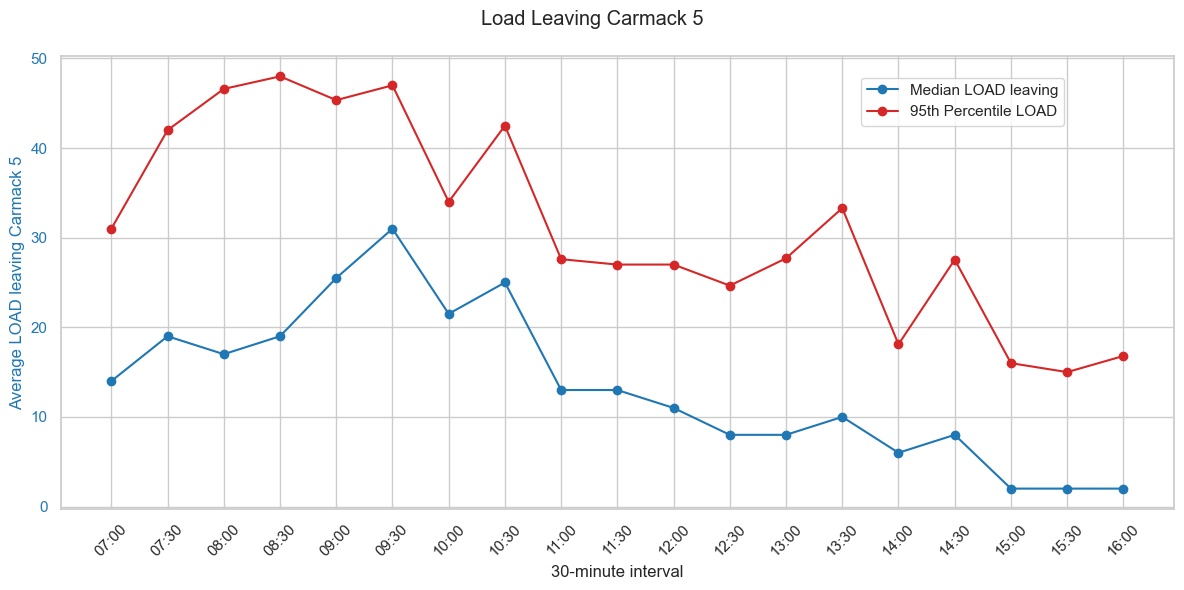

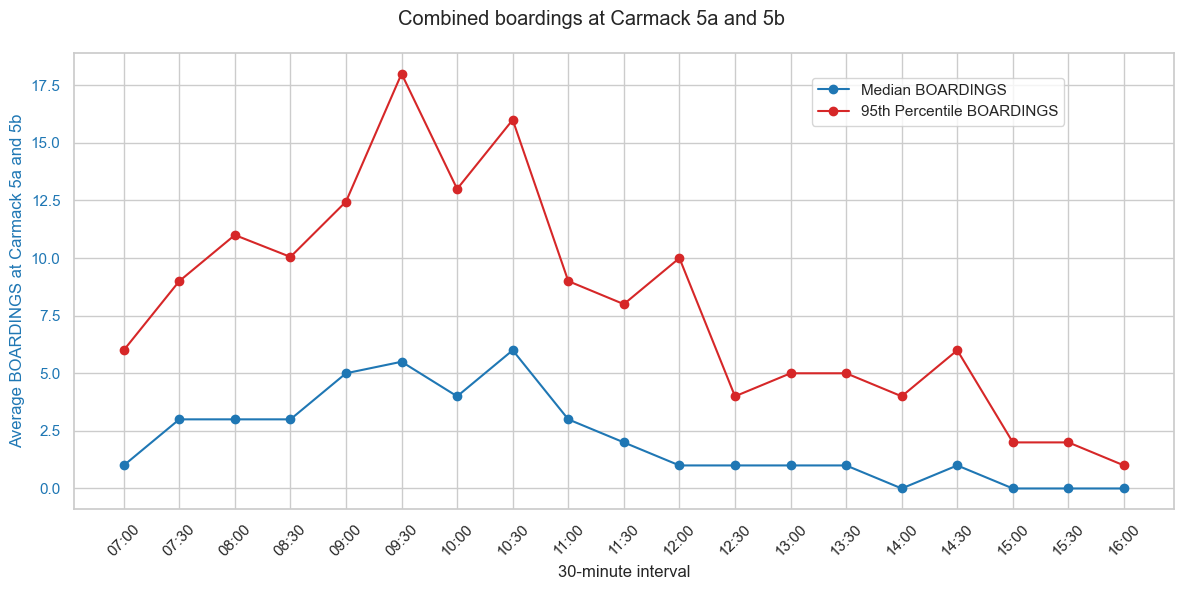

,BUCKET,Median LOAD,95th Percentile LOAD,# buses running,Median BOARDINGS,95th Percentile BOARDINGS
0,07:00,14.0,31.00,12.761905,1.0,6.00
1,07:30,19.0,42.00,10.000000,3.0,9.00
2,08:00,17.0,46.60,7.952381,3.0,11.00
3,08:30,19.0,48.00,6.952381,3.0,10.05
4,09:00,25.5,45.35,6.095238,5.0,12.45
5,09:30,31.0,47.00,3.000000,5.5,18.00
6,10:00,21.5,34.00,3.000000,4.0,13.00
7,10:30,25.0,42.50,3.000000,6.0,16.00
8,11:00,13.0,27.60,3.000000,3.0,9.00
9,11:30,13.0,27.00,3.000000,2.0,8.00


In [ ]:
morning_start = pd.to_datetime('07:00').time()
morning_end = pd.to_datetime('12:30').time()

# every event at Carmack 5B (stop 95), the LOAD there IS the load on the bus as it leaves that stop
carmack_5b_df = aug_mc_df[aug_mc_df['STOP_ID'] == CARMACK_5B].copy()
carmack_5b_df = carmack_5b_df[
    (carmack_5b_df['ARRIVAL'].dt.time >= morning_start) &
    (carmack_5b_df['ARRIVAL'].dt.time < morning_end)
]
carmack_5b_df['BUCKET'] = carmack_5b_df['ARRIVAL'].dt.floor('30min').dt.strftime('%H:%M')

mean_load_by_bucket = (
    carmack_5b_df.groupby('BUCKET', as_index=False)['LOAD']
    .mean()
    .sort_values('BUCKET')
)

median_load_by_bucket = (
    carmack_5b_df.groupby('BUCKET', as_index=False)['LOAD']
    .median()
    .sort_values('BUCKET')
)

p95_load_by_bucket = (
    carmack_5b_df.groupby('BUCKET', as_index=False)['LOAD']
    .quantile(0.95)
    .sort_values('BUCKET')
)

# distinct buses active per bucket, averaged across sampled days, as a proxy for service level
morning_mc_df = aug_mc_df[
    (aug_mc_df['ARRIVAL'].dt.time >= morning_start) &
    (aug_mc_df['ARRIVAL'].dt.time < morning_end)
].copy()
morning_mc_df['BUCKET'] = morning_mc_df['ARRIVAL'].dt.floor('30min').dt.strftime('%H:%M')

buses_by_bucket = (
    morning_mc_df.groupby(['DATE', 'BUCKET'])['BUS_ID']
    .nunique()
    .reset_index()
    .groupby('BUCKET')['BUS_ID']
    .mean()
    .reindex(mean_load_by_bucket['BUCKET'])
)

fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(median_load_by_bucket['BUCKET'], median_load_by_bucket['LOAD'], marker='o', color='tab:blue', label='Median LOAD leaving')
ax1.set_xlabel('30-minute interval')
ax1.set_ylabel('Average LOAD leaving Carmack 5', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.tick_params(axis='x', rotation=45)

# ax2 = ax1.twinx()
# ax2.plot(median_load_by_bucket['BUCKET'], median_load_by_bucket['LOAD'], marker='o', color='tab:green', label='Median LOAD leaving stop 95')
# ax2.set_xlabel('30-minute interval')
# ax2.set_ylabel('Median LOAD leaving Carmack 5 (stop 95)', color='tab:green')
# ax2.tick_params(axis='y', labelcolor='tab:green')
# ax2.tick_params(axis='x', rotation=45)


ax1.plot(p95_load_by_bucket['BUCKET'], p95_load_by_bucket['LOAD'], marker='o', color='tab:red', label='95th Percentile LOAD')


# ax2 = ax1.twinx()
# ax2.bar(mean_load_by_bucket['BUCKET'], buses_by_bucket.values, alpha=0.25, color='tab:orange', label='Avg. distinct buses running')
# ax2.set_ylabel('Avg. distinct buses running', color='tab:orange')
# ax2.tick_params(axis='y', labelcolor='tab:orange')

fig.suptitle('Load Leaving Carmack 5')
fig.legend(loc='upper right', bbox_to_anchor=(0.9, 0.88))
fig.tight_layout()
plt.show()

#########################
# plot the boardings at carmack 5a and 5b

carmack_5a_5b_df = aug_mc_df[aug_mc_df['STOP_ID'].isin([CARMACK_5A, CARMACK_5B])].copy()
fig, ax1 = plt.subplots(figsize=(12, 6))

carmack_5a_5b_df['BUCKET'] = carmack_5a_5b_df['ARRIVAL'].dt.floor('30min').dt.strftime('%H:%M')

carmack_5a_5b_df = carmack_5a_5b_df[
    (carmack_5a_5b_df['ARRIVAL'].dt.time >= morning_start) &
    (carmack_5a_5b_df['ARRIVAL'].dt.time < morning_end)
]

median_boardings_by_bucket = (
    carmack_5a_5b_df.groupby('BUCKET', as_index=False)['BOARDINGS']
    .median()
    .sort_values('BUCKET')
)

p95_boardings_by_bucket = (
    carmack_5a_5b_df.groupby('BUCKET', as_index=False)['BOARDINGS']
    .quantile(0.95)
    .sort_values('BUCKET')
)

ax1.plot(median_boardings_by_bucket['BUCKET'], median_boardings_by_bucket['BOARDINGS'], marker='o', color='tab:blue', label='Median BOARDINGS')
ax1.set_xlabel('30-minute interval')
ax1.set_ylabel('Average BOARDINGS at Carmack 5a and 5b', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.tick_params(axis='x', rotation=45)

ax1.plot(p95_boardings_by_bucket['BUCKET'], p95_boardings_by_bucket['BOARDINGS'], marker='o', color='tab:red', label='95th Percentile BOARDINGS')

fig.suptitle('Combined boardings at Carmack 5a and 5b')
fig.legend(loc='upper right', bbox_to_anchor=(0.9, 0.88))
fig.tight_layout()
plt.show()

##################


at_a_glance = median_load_by_bucket.merge(how='left', right=p95_load_by_bucket, on='BUCKET')
at_a_glance = at_a_glance.merge(how='left', right=buses_by_bucket.reset_index(), on='BUCKET')
at_a_glance = at_a_glance.merge(how='left', right=median_boardings_by_bucket, on='BUCKET')
at_a_glance = at_a_glance.merge(how='left', right=p95_boardings_by_bucket, on='BUCKET')

at_a_glance = at_a_glance.rename(columns={
    'LOAD_x': 'Median LOAD',
    'LOAD_y': '95th Percentile LOAD',
    'BUS_ID': '# buses running',
    'BOARDINGS_x': 'Median BOARDINGS',
    'BOARDINGS_y': '95th Percentile BOARDINGS'
})

display(at_a_glance)

# display(median_load_by_bucket)
# display(p95_load_by_bucket)
# display(buses_by_bucket)
